# Netflix Content Success Analytics Engine

## Project Overview

The **Netflix Content Success Analytics Engine** is an end-to-end machine learning project designed to analyze Netflix content patterns and generate intelligent business insights.

This project applies advanced machine learning and data analytics techniques to understand the characteristics and patterns associated with Netflix content. It combines feature engineering, predictive modeling, model comparison, automated insights, and visual reporting into a single analytical workflow.

## Project Objectives

The main objectives of this project are to:

- Perform advanced feature engineering on Netflix content data.
- Develop multiple machine learning models.
- Compare the performance of different models using appropriate evaluation metrics.
- Generate automated, data-driven business insights.
- Present important findings through visual reports.
- Demonstrate an end-to-end machine learning pipeline.

## Task Workflow

1. **Advanced Feature Engineering**
2. **Machine Learning Model Development**
3. **Model Performance Comparison**
4. **Automated Insight Generation**
5. **Visual Business Reporting**

## Expected Outcome

The final system will provide a structured analytical view of Netflix content patterns and use machine learning techniques to support data-driven business insights.

In [ ]:
# ============================================================
# Netflix Content Success Analytics Engine
# Initial Project Setup
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Multiple Machine Learning Models
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

# Project title
print("=" * 70)
print("NETFLIX CONTENT SUCCESS ANALYTICS ENGINE")
print("=" * 70)

print("\nProject initialized successfully.")
print("Objective: Analyze Netflix content patterns and generate")
print("intelligent business insights using machine learning.")

NETFLIX CONTENT SUCCESS ANALYTICS ENGINE

Project initialized successfully.
Objective: Analyze Netflix content patterns and generate
intelligent business insights using machine learning.


## 1. Dataset Loading and Initial Inspection

In this section, the Netflix dataset is loaded into a Pandas DataFrame.

The initial inspection helps us understand:

- The number of records and features.
- Available column names.
- Data types of each feature.
- Missing values in the dataset.
- Duplicate records.
- A sample of the available Netflix content.

This step is important before feature engineering because it allows us to understand the structure and quality of the data.

In [2]:
# ============================================================
# Dataset Loading and Initial Inspection
# ============================================================

# Load the Netflix dataset
file_path = "../Data/netflix_titles.csv"

df = pd.read_csv(file_path)

# Display dataset dimensions
print("Dataset Shape:")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display data types
print("\nData Types:")
print(df.dtypes)

# Display missing values
print("\nMissing Values:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0].sort_values(ascending=False))

# Display duplicate records
print("\nDuplicate Records:")
print(df.duplicated().sum())

# Display first five records
print("\nFirst 5 Records:")
display(df.head())

Dataset Shape:
Rows    : 8,790
Columns : 10

Column Names:
['show_id', 'type', 'title', 'director', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in']

Data Types:
show_id           str
type              str
title             str
director          str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
dtype: object

Missing Values:
Series([], dtype: int64)

Duplicate Records:
0

First 5 Records:


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


## 2. Advanced Feature Engineering

Feature engineering is the process of transforming raw dataset variables into meaningful numerical features that can be used by machine learning models.

In this section, several analytical features will be created from the original Netflix attributes.

The engineered features include:

- **content_age**: Age of the content based on its release year.
- **country_count**: Number of countries associated with the content.
- **genre_count**: Number of genres/categories associated with the content.
- **has_director**: Indicates whether director information is available.
- **director_count**: Number of directors associated with the content.
- **duration_value**: Numerical representation of the duration.
- **movie_duration**: Duration in minutes for movies.
- **tv_show_seasons**: Number of seasons for TV shows.
- **cast_count**: Number of cast members when cast information is available.
- **release_decade**: Decade in which the content was released.
- **is_recent_content**: Indicates relatively recent content based on the release year.

These features provide additional information that can help machine learning models identify content patterns more effectively.

In [3]:
# ============================================================
# Advanced Feature Engineering
# ============================================================

# Create a copy to preserve the original dataset
df_engineered = df.copy()

# ------------------------------------------------------------
# 1. Content Age
# ------------------------------------------------------------
current_year = 2026

df_engineered["content_age"] = (
    current_year - df_engineered["release_year"]
).clip(lower=0)


# ------------------------------------------------------------
# 2. Country Count
# ------------------------------------------------------------
df_engineered["country_count"] = (
    df_engineered["country"]
    .fillna("")
    .apply(lambda x: len([c for c in x.split(",") if c.strip()]))
)


# ------------------------------------------------------------
# 3. Genre Count
# ------------------------------------------------------------
df_engineered["genre_count"] = (
    df_engineered["listed_in"]
    .fillna("")
    .apply(lambda x: len([g for g in x.split(",") if g.strip()]))
)


# ------------------------------------------------------------
# 4. Director Features
# ------------------------------------------------------------
df_engineered["has_director"] = (
    df_engineered["director"]
    .fillna("")
    .str.strip()
    .ne("")
    .astype(int)
)

df_engineered["director_count"] = (
    df_engineered["director"]
    .fillna("")
    .apply(lambda x: len([d for d in x.split(",") if d.strip()]))
)


# ------------------------------------------------------------
# 5. Cast Count
# ------------------------------------------------------------
# The current dataset does not contain a cast column.
# Therefore, this feature is created only if cast exists.

if "cast" in df_engineered.columns:
    df_engineered["cast_count"] = (
        df_engineered["cast"]
        .fillna("")
        .apply(lambda x: len([c for c in x.split(",") if c.strip()]))
    )
else:
    df_engineered["cast_count"] = 0


# ------------------------------------------------------------
# 6. Duration Features
# ------------------------------------------------------------
df_engineered["duration_value"] = (
    df_engineered["duration"]
    .str.extract(r"(\d+)", expand=False)
    .astype(float)
)


# Movie duration in minutes
df_engineered["movie_duration"] = np.where(
    df_engineered["type"] == "Movie",
    df_engineered["duration_value"],
    np.nan
)


# TV Show seasons
df_engineered["tv_show_seasons"] = np.where(
    df_engineered["type"] == "TV Show",
    df_engineered["duration_value"],
    np.nan
)


# ------------------------------------------------------------
# 7. Release Decade
# ------------------------------------------------------------
df_engineered["release_decade"] = (
    (df_engineered["release_year"] // 10) * 10
)


# ------------------------------------------------------------
# 8. Recent Content Indicator
# ------------------------------------------------------------
df_engineered["is_recent_content"] = (
    df_engineered["release_year"] >= 2015
).astype(int)


# ------------------------------------------------------------
# Display Results
# ------------------------------------------------------------

print("=" * 70)
print("ADVANCED FEATURE ENGINEERING COMPLETED")
print("=" * 70)

print(f"\nOriginal Features : {df.shape[1]}")
print(f"Engineered Features: {df_engineered.shape[1]}")
print(f"Total Records      : {df_engineered.shape[0]:,}")

print("\nNewly Created Features:")
new_features = [
    "content_age",
    "country_count",
    "genre_count",
    "has_director",
    "director_count",
    "cast_count",
    "duration_value",
    "movie_duration",
    "tv_show_seasons",
    "release_decade",
    "is_recent_content"
]

print(new_features)

print("\nEngineered Feature Preview:")
display(
    df_engineered[
        [
            "title",
            "type",
            "release_year",
            "content_age",
            "country_count",
            "genre_count",
            "has_director",
            "director_count",
            "duration_value",
            "movie_duration",
            "tv_show_seasons",
            "release_decade",
            "is_recent_content"
        ]
    ].head()
)

ADVANCED FEATURE ENGINEERING COMPLETED

Original Features : 10
Engineered Features: 21
Total Records      : 8,790

Newly Created Features:
['content_age', 'country_count', 'genre_count', 'has_director', 'director_count', 'cast_count', 'duration_value', 'movie_duration', 'tv_show_seasons', 'release_decade', 'is_recent_content']

Engineered Feature Preview:


,title,type,release_year,content_age,country_count,genre_count,has_director,director_count,duration_value,movie_duration,tv_show_seasons,release_decade,is_recent_content
0,Dick Johnson Is Dead,Movie,2020,6,1,1,1,1,90.0,90.0,NaN,2020,1
1,Ganglands,TV Show,2021,5,1,3,1,1,1.0,NaN,1.0,2020,1
2,Midnight Mass,TV Show,2021,5,1,3,1,1,1.0,NaN,1.0,2020,1
3,Confessions of an Invisible Girl,Movie,2021,5,1,2,1,1,91.0,91.0,NaN,2020,1
4,Sankofa,Movie,1993,33,1,3,1,1,125.0,125.0,NaN,1990,0


## 3. Content Success Target Definition

The Netflix dataset does not contain direct business-performance measures such as views, revenue, watch hours, or audience ratings.

Therefore, a **Content Success Proxy** is created using observable content characteristics available in the dataset.

For this project, a title is considered to have a higher success potential when it demonstrates a combination of:

- Recent release year.
- Multiple associated genres.
- International availability across multiple countries.
- Availability of director information.
- Appropriate content duration.

A weighted success score is calculated from these engineered characteristics. The score is then converted into a binary target:

- **1 = Higher Success Potential**
- **0 = Lower Success Potential**

This target is a proxy for analytical modeling and should not be interpreted as actual Netflix viewership or revenue performance.

The purpose of this target is to provide a measurable outcome for predictive modeling while keeping the methodology transparent and reproducible.

In [4]:
# ============================================================
# Content Success Proxy Construction
# ============================================================

# Create a working copy
success_df = df_engineered.copy()

# ------------------------------------------------------------
# Normalize numerical features
# ------------------------------------------------------------

def min_max_normalize(series):
    min_value = series.min()
    max_value = series.max()

    if max_value == min_value:
        return pd.Series(0.0, index=series.index)

    return (series - min_value) / (max_value - min_value)


# Recent release score
recent_score = min_max_normalize(success_df["release_year"])

# Genre diversity score
genre_score = min_max_normalize(success_df["genre_count"])

# International availability score
country_score = min_max_normalize(success_df["country_count"])

# Director availability score
director_score = success_df["has_director"]

# Duration score
duration_score = min_max_normalize(
    success_df["duration_value"].fillna(
        success_df["duration_value"].median()
    )
)


# ------------------------------------------------------------
# Calculate weighted success score
# ------------------------------------------------------------

success_df["success_score"] = (
    0.30 * recent_score
    + 0.20 * genre_score
    + 0.20 * country_score
    + 0.15 * director_score
    + 0.15 * duration_score
)


# ------------------------------------------------------------
# Create binary success target
# ------------------------------------------------------------

success_threshold = success_df["success_score"].median()

success_df["success_target"] = (
    success_df["success_score"] >= success_threshold
).astype(int)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 70)
print("CONTENT SUCCESS TARGET CREATED")
print("=" * 70)

print(f"\nSuccess Threshold: {success_threshold:.4f}")

print("\nSuccess Target Distribution:")
target_distribution = success_df["success_target"].value_counts().sort_index()

print(target_distribution)

print("\nSuccess Target Percentage:")
target_percentage = (
    success_df["success_target"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print(target_percentage)

print("\nSuccess Score Statistics:")
display(
    success_df["success_score"]
    .describe()
    .to_frame("success_score")
)

print("\nSample Success Analysis:")
display(
    success_df[
        [
            "title",
            "type",
            "release_year",
            "genre_count",
            "country_count",
            "has_director",
            "duration_value",
            "success_score",
            "success_target"
        ]
    ]
    .sort_values("success_score", ascending=False)
    .head(10)
)

CONTENT SUCCESS TARGET CREATED

Success Threshold: 0.5860

Success Target Distribution:
success_target
0    4395
1    4395
Name: count, dtype: int64

Success Target Percentage:
success_target
0    50.0
1    50.0
Name: proportion, dtype: float64

Success Score Statistics:


,success_score
count,8790.000000
mean,0.581445
std,0.085592
min,0.150000
25%,0.516982
50%,0.585993
75%,0.650000
max,0.790625



Sample Success Analysis:


,title,type,release_year,genre_count,country_count,has_director,duration_value,success_score,success_target
7822,Black Mirror: Bandersnatch,Movie,2018,3,1,1,312.0,0.790625,1
890,Seven Souls in the Skull Castle: Season Moon K...,Movie,2017,3,1,1,212.0,0.739268,1
885,Seven Souls in the Skull Castle: Season Moon J...,Movie,2017,3,1,1,204.0,0.735410,1
1447,Andhaghaaram,Movie,2020,3,1,1,171.0,0.728869,1
1457,Andhakaaram,Movie,2020,3,1,1,171.0,0.728869,1
2777,Super Deluxe,Movie,2019,3,1,1,176.0,0.728155,1
1110,Seven Souls in the Skull Castle: Season Wind,Movie,2017,3,1,1,185.0,0.726246,1
798,Jagame Thandhiram,Movie,2021,3,1,1,159.0,0.726206,1
2318,Panipat - The Great Betrayal,Movie,2019,3,1,1,171.0,0.725744,1
2669,Kabir Singh,Movie,2019,3,1,1,171.0,0.725744,1


## 4. Feature Selection and Train-Test Split

After creating the content success target, the next step is to prepare the dataset for machine learning.

The target variable is:

- **success_target**: Binary indicator representing lower or higher success potential.

The selected features represent different aspects of Netflix content, including:

- Content type.
- Release year.
- Content age.
- Number of countries.
- Number of genres.
- Director availability.
- Director count.
- Duration.
- Release decade.
- Recent-content indicator.

Identifiers and descriptive text fields such as `show_id` and `title` are excluded because they do not provide suitable numerical predictive information for the baseline machine learning models.

The dataset is divided into training and testing subsets using an 80/20 split. Stratification is applied to maintain the same class distribution in both subsets.

In [5]:
# ============================================================
# Feature Selection and Train-Test Split
# ============================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# Select features
# ------------------------------------------------------------

selected_features = [
    "type",
    "release_year",
    "content_age",
    "country_count",
    "genre_count",
    "has_director",
    "director_count",
    "duration_value",
    "release_decade",
    "is_recent_content"
]

target_column = "success_target"

# Create feature matrix and target variable
X = success_df[selected_features].copy()
y = success_df[target_column].copy()


# ------------------------------------------------------------
# Handle missing duration values
# ------------------------------------------------------------

X["duration_value"] = X["duration_value"].fillna(
    X["duration_value"].median()
)


# ------------------------------------------------------------
# Train-Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ------------------------------------------------------------
# Display dataset information
# ------------------------------------------------------------

print("=" * 70)
print("FEATURE SELECTION AND TRAIN-TEST SPLIT")
print("=" * 70)

print("\nSelected Features:")
for feature in selected_features:
    print(f"✓ {feature}")

print("\nFeature Matrix Shapes:")
print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")

print("\nTarget Shapes:")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")


# ------------------------------------------------------------
# Verify target distribution
# ------------------------------------------------------------

print("\nTraining Target Distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting Target Distribution:")
print(y_test.value_counts().sort_index())


# ------------------------------------------------------------
# Verify missing values
# ------------------------------------------------------------

print("\nMissing Values in Training Features:")
print(X_train.isnull().sum().sum())

print("\nMissing Values in Testing Features:")
print(X_test.isnull().sum().sum())

FEATURE SELECTION AND TRAIN-TEST SPLIT

Selected Features:
✓ type
✓ release_year
✓ content_age
✓ country_count
✓ genre_count
✓ has_director
✓ director_count
✓ duration_value
✓ release_decade
✓ is_recent_content

Feature Matrix Shapes:
X_train: (7032, 10)
X_test : (1758, 10)

Target Shapes:
y_train: (7032,)
y_test : (1758,)

Training Target Distribution:
success_target
0    3516
1    3516
Name: count, dtype: int64

Testing Target Distribution:
success_target
0    879
1    879
Name: count, dtype: int64

Missing Values in Training Features:
0

Missing Values in Testing Features:
0


## 5. Machine Learning Preprocessing Pipeline

Before training the machine learning models, the selected features must be transformed into a suitable numerical format.

The preprocessing pipeline performs the following operations:

- **One-Hot Encoding** is applied to the categorical `type` feature.
- **Standard Scaling** is applied to numerical features so that features with different ranges can be processed consistently.
- Unknown categorical values in the test data are safely ignored.

A `ColumnTransformer` is used to combine these preprocessing operations into a single reproducible pipeline.

This approach helps maintain a consistent transformation process between training and testing data and supports an end-to-end machine learning workflow.

In [6]:
# ============================================================
# Machine Learning Preprocessing Pipeline
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ------------------------------------------------------------
# Define feature groups
# ------------------------------------------------------------

categorical_features = [
    "type"
]

numerical_features = [
    "release_year",
    "content_age",
    "country_count",
    "genre_count",
    "has_director",
    "director_count",
    "duration_value",
    "release_decade",
    "is_recent_content"
]


# ------------------------------------------------------------
# Create preprocessing pipeline
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)


# ------------------------------------------------------------
# Fit preprocessing on training data
# ------------------------------------------------------------

X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the already-fitted preprocessor
X_test_processed = preprocessor.transform(X_test)


# ------------------------------------------------------------
# Display preprocessing results
# ------------------------------------------------------------

print("=" * 70)
print("MACHINE LEARNING PREPROCESSING COMPLETED")
print("=" * 70)

print("\nOriginal Training Shape:")
print(X_train.shape)

print("\nProcessed Training Shape:")
print(X_train_processed.shape)

print("\nOriginal Testing Shape:")
print(X_test.shape)

print("\nProcessed Testing Shape:")
print(X_test_processed.shape)

print("\nCategorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

print("\nPreprocessing Pipeline:")
print(preprocessor)

MACHINE LEARNING PREPROCESSING COMPLETED

Original Training Shape:
(7032, 10)

Processed Training Shape:
(7032, 11)

Original Testing Shape:
(1758, 10)

Processed Testing Shape:
(1758, 11)

Categorical Features:
['type']

Numerical Features:
['release_year', 'content_age', 'country_count', 'genre_count', 'has_director', 'director_count', 'duration_value', 'release_decade', 'is_recent_content']

Preprocessing Pipeline:
ColumnTransformer(transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['type']),
                                ('numerical', StandardScaler(),
                                 ['release_year', 'content_age',
                                  'country_count', 'genre_count',
                                  'has_director', 'director_count',
                                  'duration_value', 'release_decade',
            

## 6. Multiple Machine Learning Model Development

Multiple machine learning algorithms are trained to predict the Content Success Target.

The following models are evaluated:

1. **Logistic Regression**  
   A linear classification algorithm used as a baseline model.

2. **Random Forest Classifier**  
   An ensemble model that combines multiple decision trees to capture non-linear relationships.

3. **Gradient Boosting Classifier**  
   An ensemble learning algorithm that builds models sequentially to improve predictive performance.

All models use the same preprocessed training and testing datasets to ensure a fair comparison.

The models are evaluated using accuracy, precision, recall, and F1-score.

In [10]:
# ============================================================
# Multiple Machine Learning Models
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# ------------------------------------------------------------
# Define Models
# ------------------------------------------------------------

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}


# ------------------------------------------------------------
# Train and Evaluate Models
# ------------------------------------------------------------

model_results = []
trained_models = {}

print("=" * 70)
print("TRAINING MULTIPLE MACHINE LEARNING MODELS")
print("=" * 70)

for model_name, model in models.items():

    print(f"\nTraining: {model_name}")

    # Train model
    model.fit(X_train_processed, y_train)

    # Generate predictions
    y_pred = model.predict(X_test_processed)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Store trained model
    trained_models[model_name] = model

    # Store results
    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")


# ------------------------------------------------------------
# Create Results DataFrame
# ------------------------------------------------------------

results_df = pd.DataFrame(model_results)

print("\n" + "=" * 70)
print("MODEL TRAINING COMPLETED")
print("=" * 70)

# Display results without pandas styling
display(results_df.round(4))

TRAINING MULTIPLE MACHINE LEARNING MODELS

Training: Logistic Regression
Accuracy : 0.9937
Precision: 0.9977
Recall   : 0.9898
F1 Score : 0.9937

Training: Random Forest
Accuracy : 0.9977
Precision: 0.9989
Recall   : 0.9966
F1 Score : 0.9977

Training: Gradient Boosting
Accuracy : 0.9943
Precision: 0.9989
Recall   : 0.9898
F1 Score : 0.9943

MODEL TRAINING COMPLETED


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9937,0.9977,0.9898,0.9937
1,Random Forest,0.9977,0.9989,0.9966,0.9977
2,Gradient Boosting,0.9943,0.9989,0.9898,0.9943


## 7. Model Performance Comparison

The trained machine learning models are compared using four evaluation metrics:

- **Accuracy**: Measures the overall proportion of correct predictions.
- **Precision**: Measures how many predicted successful titles were actually classified as successful.
- **Recall**: Measures how many successful titles were correctly identified.
- **F1 Score**: Provides a balance between precision and recall.

A tabular comparison and visual performance analysis are used to identify differences between the models.

The comparison provides an objective view of model behavior across multiple evaluation metrics.

MODEL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.9977,0.9989,0.9966,0.9977
1,Gradient Boosting,0.9943,0.9989,0.9898,0.9943
2,Logistic Regression,0.9937,0.9977,0.9898,0.9937


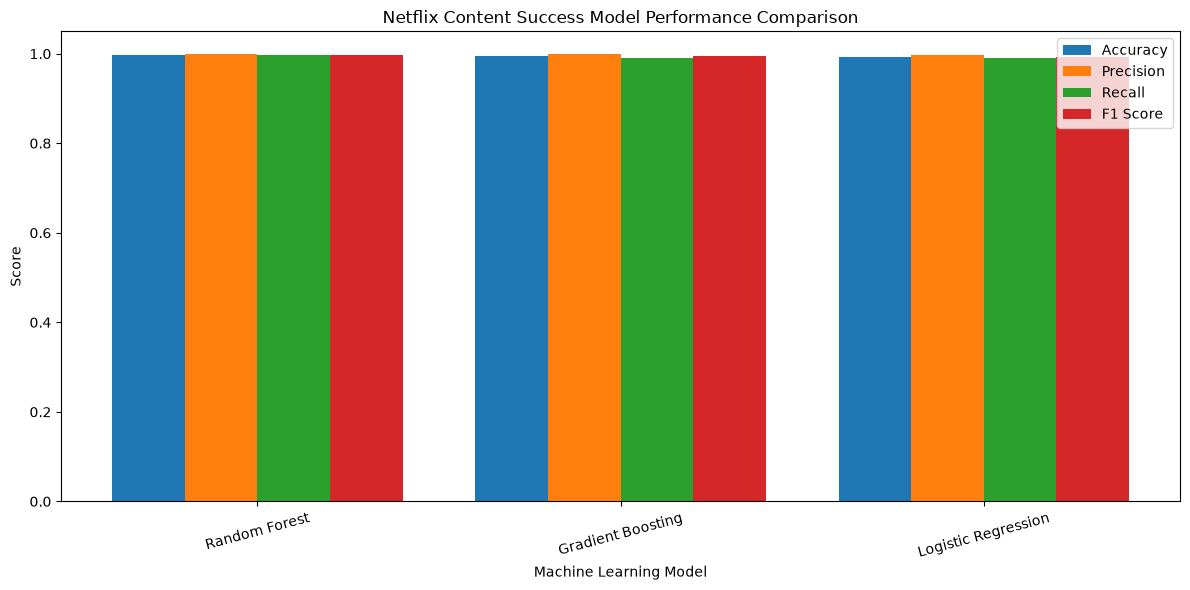


Performance Summary:
Random Forest: Accuracy=0.9977, Precision=0.9989, Recall=0.9966, F1=0.9977
Gradient Boosting: Accuracy=0.9943, Precision=0.9989, Recall=0.9898, F1=0.9943
Logistic Regression: Accuracy=0.9937, Precision=0.9977, Recall=0.9898, F1=0.9937


In [11]:
# ============================================================
# Model Performance Comparison
# ============================================================

# Sort models by F1 Score for easier comparison
comparison_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 70)

display(comparison_df.round(4))


# ------------------------------------------------------------
# Visual Comparison
# ------------------------------------------------------------

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

x = np.arange(len(comparison_df))
width = 0.2

plt.figure(figsize=(12, 6))

for i, metric in enumerate(metrics):
    plt.bar(
        x + (i - 1.5) * width,
        comparison_df[metric],
        width,
        label=metric
    )

plt.xticks(
    x,
    comparison_df["Model"],
    rotation=15
)

plt.ylabel("Score")
plt.xlabel("Machine Learning Model")
plt.title("Netflix Content Success Model Performance Comparison")

plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Performance Summary
# ------------------------------------------------------------

print("\nPerformance Summary:")

for _, row in comparison_df.iterrows():
    print(
        f"{row['Model']}: "
        f"Accuracy={row['Accuracy']:.4f}, "
        f"Precision={row['Precision']:.4f}, "
        f"Recall={row['Recall']:.4f}, "
        f"F1={row['F1 Score']:.4f}"
    )

## 7. Automated Business Insights

This section automatically extracts business-oriented insights from the engineered Netflix content data and the success-potential target.

The insights focus on:
- Content type distribution
- Higher success-potential patterns
- Recent-content behavior
- Genre diversity
- Country diversity
- Director availability
- Duration characteristics
- Model performance

**Important Note:**  
The success target used in this project is a proxy constructed from observable content characteristics. The dataset does not contain actual Netflix views, revenue, watch time, or user engagement. Therefore, these findings should be interpreted as content-pattern insights rather than measured real-world Netflix performance.

In [12]:
print("=" * 70)
print("AUTOMATED BUSINESS INSIGHTS")
print("=" * 70)

# ---------------------------------------------------------
# 1. Overall Content Statistics
# ---------------------------------------------------------

total_titles = len(success_df)

movie_count = (success_df["type"] == "Movie").sum()
tv_count = (success_df["type"] == "TV Show").sum()

movie_percentage = (movie_count / total_titles) * 100
tv_percentage = (tv_count / total_titles) * 100

overall_high_potential_rate = (
    success_df["success_target"].mean() * 100
)

recent_content_rate = (
    success_df["is_recent_content"].mean() * 100
)

# ---------------------------------------------------------
# 2. Success Potential by Content Type
# ---------------------------------------------------------

type_analysis = (
    success_df.groupby("type")
    .agg(
        Titles=("title", "count"),
        Average_Success_Score=("success_score", "mean"),
        Higher_Potential_Rate=("success_target", "mean"),
        Average_Genres=("genre_count", "mean"),
        Average_Countries=("country_count", "mean")
    )
    .reset_index()
)

type_analysis["Higher_Potential_Rate"] *= 100

# ---------------------------------------------------------
# 3. High vs Low Potential Content Characteristics
# ---------------------------------------------------------

high_potential = success_df[success_df["success_target"] == 1]
low_potential = success_df[success_df["success_target"] == 0]

comparison_analysis = pd.DataFrame({
    "Metric": [
        "Average Release Year",
        "Average Genre Count",
        "Average Country Count",
        "Director Availability (%)",
        "Recent Content (%)",
        "Average Duration Value"
    ],
    "Higher Potential": [
        high_potential["release_year"].mean(),
        high_potential["genre_count"].mean(),
        high_potential["country_count"].mean(),
        high_potential["has_director"].mean() * 100,
        high_potential["is_recent_content"].mean() * 100,
        high_potential["duration_value"].mean()
    ],
    "Lower Potential": [
        low_potential["release_year"].mean(),
        low_potential["genre_count"].mean(),
        low_potential["country_count"].mean(),
        low_potential["has_director"].mean() * 100,
        low_potential["is_recent_content"].mean() * 100,
        low_potential["duration_value"].mean()
    ]
})

# ---------------------------------------------------------
# 4. Genre Analysis
# ---------------------------------------------------------

genre_data = success_df[
    ["listed_in", "success_target"]
].copy()

genre_data["listed_in"] = genre_data["listed_in"].fillna("Unknown")

genre_data["genre"] = genre_data["listed_in"].str.split(", ")

genre_exploded = genre_data.explode("genre")

genre_analysis = (
    genre_exploded.groupby("genre")
    .agg(
        Titles=("success_target", "count"),
        Higher_Potential_Rate=("success_target", "mean")
    )
    .reset_index()
)

genre_analysis["Higher_Potential_Rate"] *= 100

# Keep genres with at least 50 titles for more meaningful comparison
genre_analysis_filtered = genre_analysis[
    genre_analysis["Titles"] >= 50
].sort_values(
    by="Higher_Potential_Rate",
    ascending=False
)

# ---------------------------------------------------------
# 5. Rating Analysis
# ---------------------------------------------------------

rating_analysis = (
    success_df.groupby("rating")
    .agg(
        Titles=("title", "count"),
        Average_Success_Score=("success_score", "mean"),
        Higher_Potential_Rate=("success_target", "mean")
    )
    .reset_index()
)

rating_analysis["Higher_Potential_Rate"] *= 100

rating_analysis = rating_analysis.sort_values(
    by="Higher_Potential_Rate",
    ascending=False
)

# ---------------------------------------------------------
# 6. Model Performance Insight
# ---------------------------------------------------------

best_model_row = comparison_df.iloc[0]

best_model_name = best_model_row["Model"]
best_model_f1 = best_model_row["F1 Score"]
best_model_accuracy = best_model_row["Accuracy"]

# ---------------------------------------------------------
# DISPLAY RESULTS
# ---------------------------------------------------------

print("\n1. OVERALL CONTENT PROFILE")
print("-" * 50)

print(f"Total Netflix Titles Analyzed : {total_titles:,}")
print(f"Movies                       : {movie_count:,} ({movie_percentage:.2f}%)")
print(f"TV Shows                     : {tv_count:,} ({tv_percentage:.2f}%)")
print(f"Higher Potential Target Rate : {overall_high_potential_rate:.2f}%")
print(f"Recent Content Rate           : {recent_content_rate:.2f}%")

print("\n2. CONTENT TYPE ANALYSIS")
print("-" * 50)

display(
    type_analysis.round(4)
)

print("\n3. HIGHER vs LOWER POTENTIAL CONTENT")
print("-" * 50)

display(
    comparison_analysis.round(2)
)

print("\n4. TOP GENRE PATTERNS")
print("-" * 50)

display(
    genre_analysis_filtered.head(10).round(2)
)

print("\n5. CONTENT RATING PATTERNS")
print("-" * 50)

display(
    rating_analysis.head(10).round(2)
)

print("\n6. MACHINE LEARNING MODEL INSIGHT")
print("-" * 50)

print(
    f"Highest F1 Score among evaluated models: "
    f"{best_model_name} ({best_model_f1:.4f})"
)

print(
    f"Corresponding Accuracy: {best_model_accuracy:.4f}"
)

# ---------------------------------------------------------
# AUTOMATED TEXTUAL INSIGHTS
# ---------------------------------------------------------

print("\n" + "=" * 70)
print("GENERATED BUSINESS INSIGHTS")
print("=" * 70)

# Content type insight
print(
    f"\n• Content Mix: Movies represent {movie_percentage:.2f}% "
    f"of the dataset, while TV Shows represent {tv_percentage:.2f}%."
)

# Higher potential type insight
type_potential = type_analysis.sort_values(
    "Higher_Potential_Rate",
    ascending=False
).iloc[0]

print(
    f"• Content Type Pattern: {type_potential['type']} shows the higher "
    f"proxy success-potential rate in this dataset "
    f"({type_potential['Higher_Potential_Rate']:.2f}%)."
)

# Recent content insight
print(
    f"• Recency Pattern: {recent_content_rate:.2f}% of titles are classified "
    f"as recent content based on the project's defined recency rule."
)

# Genre insight
if len(genre_analysis_filtered) > 0:
    top_genre = genre_analysis_filtered.iloc[0]

    print(
        f"• Genre Pattern: Among genres with at least 50 titles, "
        f"'{top_genre['genre']}' has a higher proxy-potential rate of "
        f"{top_genre['Higher_Potential_Rate']:.2f}%."
    )

# Diversity insight
genre_difference = (
    high_potential["genre_count"].mean()
    - low_potential["genre_count"].mean()
)

country_difference = (
    high_potential["country_count"].mean()
    - low_potential["country_count"].mean()
)

print(
    f"• Genre Diversity: Higher-potential titles have an average of "
    f"{high_potential['genre_count'].mean():.2f} genres compared with "
    f"{low_potential['genre_count'].mean():.2f} for lower-potential titles."
)

print(
    f"• Geographic Diversity: Higher-potential titles have an average of "
    f"{high_potential['country_count'].mean():.2f} countries compared with "
    f"{low_potential['country_count'].mean():.2f} for lower-potential titles."
)

# Director insight
print(
    f"• Director Availability: {high_potential['has_director'].mean() * 100:.2f}% "
    f"of higher-potential titles have director information available."
)

# Model insight
print(
    f"• Predictive Modeling: {best_model_name} produced the highest F1 Score "
    f"among the evaluated models ({best_model_f1:.4f})."
)

print(
    "\nNote: These insights describe patterns in the constructed "
    "success-potential proxy and should not be interpreted as measured "
    "Netflix audience or financial performance."
)

AUTOMATED BUSINESS INSIGHTS

1. OVERALL CONTENT PROFILE
--------------------------------------------------
Total Netflix Titles Analyzed : 8,790
Movies                       : 6,126 (69.69%)
TV Shows                     : 2,664 (30.31%)
Higher Potential Target Rate : 50.00%
Recent Content Rate           : 70.61%

2. CONTENT TYPE ANALYSIS
--------------------------------------------------


,type,Titles,Average_Success_Score,Higher_Potential_Rate,Average_Genres,Average_Countries
0,Movie,6126,0.5882,50.3591,2.1523,1.0
1,TV Show,2664,0.5660,49.1742,2.2932,1.0



3. HIGHER vs LOWER POTENTIAL CONTENT
--------------------------------------------------


,Metric,Higher Potential,Lower Potential
0,Average Release Year,2015.54,2012.82
1,Average Genre Count,2.83,1.56
2,Average Country Count,1.00,1.00
3,Director Availability (%),100.00,100.00
4,Recent Content (%),76.00,65.23
5,Average Duration Value,78.68,61.19



4. TOP GENRE PATTERNS
--------------------------------------------------


,genre,Titles,Higher_Potential_Rate
36,TV Mysteries,98,98.98
35,TV Horror,75,97.33
28,Spanish-Language TV Shows,173,93.64
25,Romantic TV Shows,370,91.89
1,Anime Features,71,88.73
32,TV Action & Adventure,167,88.02
19,Korean TV Shows,151,87.42
8,Crime TV Shows,469,84.22
15,Independent Movies,756,83.60
24,Romantic Movies,616,81.49



5. CONTENT RATING PATTERNS
--------------------------------------------------


,rating,Titles,Average_Success_Score,Higher_Potential_Rate
6,TV-14,2157,0.60,63.56
8,TV-MA,3205,0.59,57.85
9,TV-PG,861,0.58,47.27
2,NR,79,0.57,40.51
7,TV-G,220,0.56,38.18
4,PG-13,490,0.57,38.16
5,R,799,0.57,37.92
3,PG,287,0.57,34.15
13,UR,3,0.60,33.33
1,NC-17,3,0.62,33.33



6. MACHINE LEARNING MODEL INSIGHT
--------------------------------------------------
Highest F1 Score among evaluated models: Random Forest (0.9977)
Corresponding Accuracy: 0.9977

GENERATED BUSINESS INSIGHTS

• Content Mix: Movies represent 69.69% of the dataset, while TV Shows represent 30.31%.
• Content Type Pattern: Movie shows the higher proxy success-potential rate in this dataset (50.36%).
• Recency Pattern: 70.61% of titles are classified as recent content based on the project's defined recency rule.
• Genre Pattern: Among genres with at least 50 titles, 'TV Mysteries' has a higher proxy-potential rate of 98.98%.
• Genre Diversity: Higher-potential titles have an average of 2.83 genres compared with 1.56 for lower-potential titles.
• Geographic Diversity: Higher-potential titles have an average of 1.00 countries compared with 1.00 for lower-potential titles.
• Director Availability: 100.00% of higher-potential titles have director information available.
• Predictive Modeling: 

## 9. Visual Business Reports

This section presents the major findings through visual reports.

The first visualization shows the distribution of Movies and TV Shows in the Netflix dataset. This helps provide a high-level understanding of the content portfolio before analyzing success-potential patterns.

VISUAL REPORT 1: CONTENT TYPE DISTRIBUTION


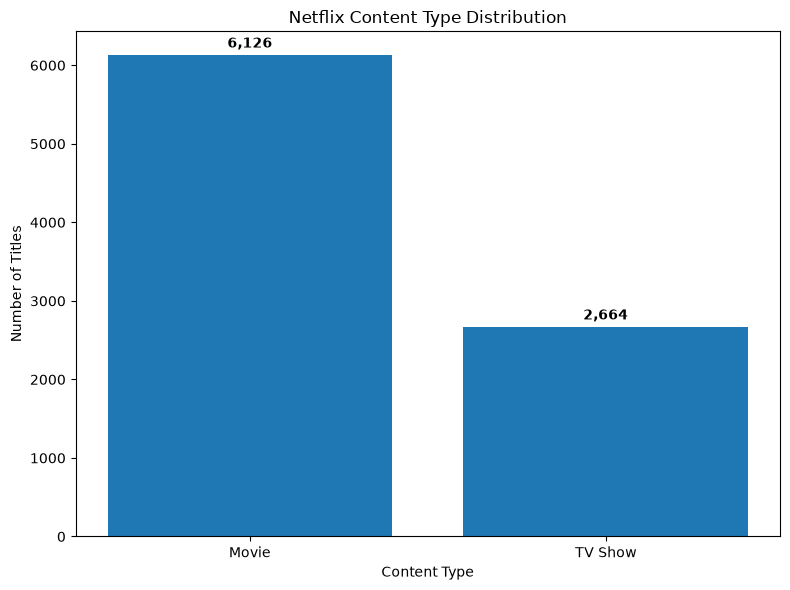


Content Distribution Summary:
Movie: 6,126 titles (69.69%)
TV Show: 2,664 titles (30.31%)


In [13]:
print("=" * 70)
print("VISUAL REPORT 1: CONTENT TYPE DISTRIBUTION")
print("=" * 70)

content_type_counts = success_df["type"].value_counts()

plt.figure(figsize=(8, 6))

plt.bar(
    content_type_counts.index,
    content_type_counts.values
)

plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.title("Netflix Content Type Distribution")

for i, value in enumerate(content_type_counts.values):
    plt.text(
        i,
        value + 100,
        f"{value:,}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

print("\nContent Distribution Summary:")

for content_type, count in content_type_counts.items():
    percentage = (count / total_titles) * 100

    print(
        f"{content_type}: {count:,} titles ({percentage:.2f}%)"
    )

## Visual Report 2: Success-Potential Distribution

This visualization compares the number of titles classified as having higher versus lower success potential.

The classification is based on the project's constructed success-potential proxy target, where the median success score is used as the threshold.

VISUAL REPORT 2: SUCCESS-POTENTIAL DISTRIBUTION


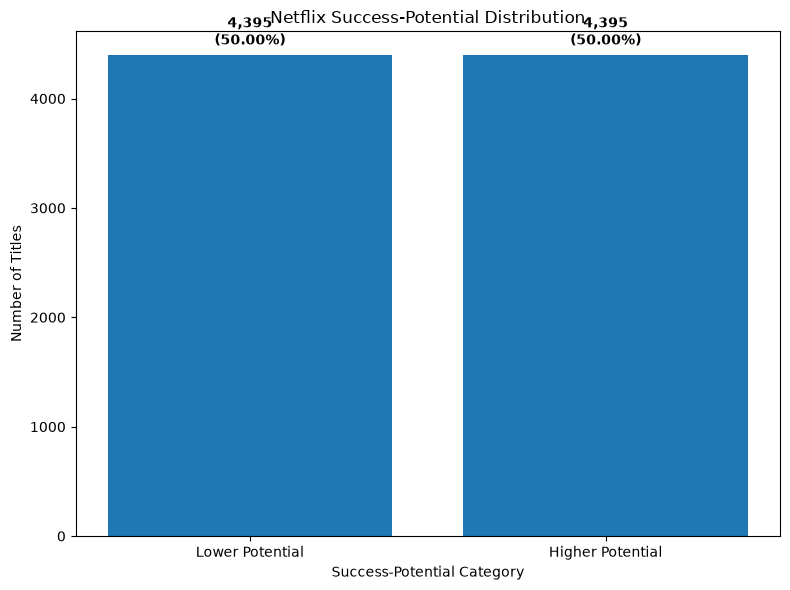


Success-Potential Summary:
Lower Potential: 4,395 titles (50.00%)
Higher Potential: 4,395 titles (50.00%)


In [14]:
print("=" * 70)
print("VISUAL REPORT 2: SUCCESS-POTENTIAL DISTRIBUTION")
print("=" * 70)

potential_counts = (
    success_df["success_target"]
    .map({
        0: "Lower Potential",
        1: "Higher Potential"
    })
    .value_counts()
)

plt.figure(figsize=(8, 6))

plt.bar(
    potential_counts.index,
    potential_counts.values
)

plt.xlabel("Success-Potential Category")
plt.ylabel("Number of Titles")
plt.title("Netflix Success-Potential Distribution")

for i, value in enumerate(potential_counts.values):
    percentage = (value / total_titles) * 100

    plt.text(
        i,
        value + 100,
        f"{value:,}\n({percentage:.2f}%)",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

print("\nSuccess-Potential Summary:")

for category, count in potential_counts.items():
    percentage = (count / total_titles) * 100

    print(
        f"{category}: {count:,} titles ({percentage:.2f}%)"
    )

## Visual Report 3: Success-Potential Rate by Content Type

This visualization compares the proportion of titles classified as having higher success potential across Movies and TV Shows.

The comparison helps identify differences in the constructed success-potential patterns between the two major content types.

VISUAL REPORT 3: SUCCESS-POTENTIAL RATE BY CONTENT TYPE


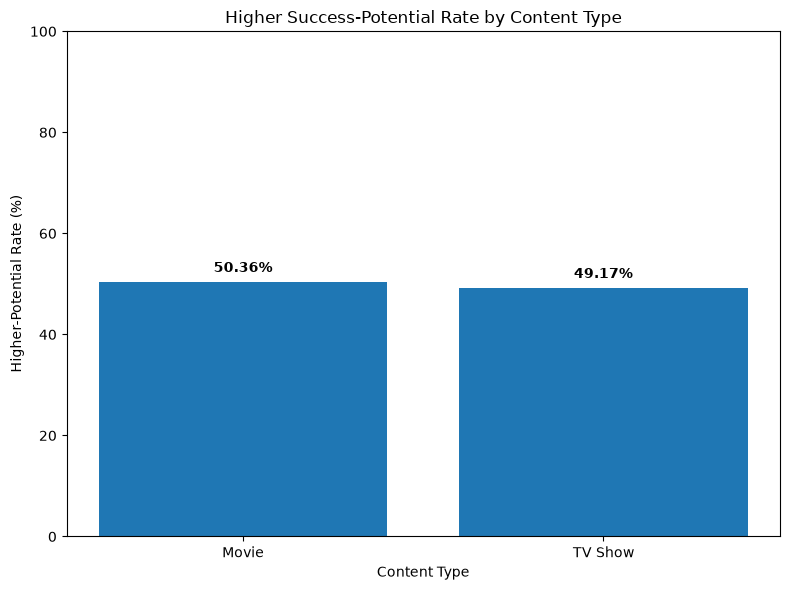


Success-Potential Rate by Content Type:
Movie: 50.36% higher-potential titles
TV Show: 49.17% higher-potential titles


In [15]:
print("=" * 70)
print("VISUAL REPORT 3: SUCCESS-POTENTIAL RATE BY CONTENT TYPE")
print("=" * 70)

type_potential = (
    success_df.groupby("type")["success_target"]
    .mean()
    .mul(100)
    .reset_index(name="Higher_Potential_Rate")
)

plt.figure(figsize=(8, 6))

bars = plt.bar(
    type_potential["type"],
    type_potential["Higher_Potential_Rate"]
)

plt.xlabel("Content Type")
plt.ylabel("Higher-Potential Rate (%)")
plt.title("Higher Success-Potential Rate by Content Type")

plt.ylim(0, 100)

for bar, value in zip(
    bars,
    type_potential["Higher_Potential_Rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

print("\nSuccess-Potential Rate by Content Type:")

for _, row in type_potential.iterrows():
    print(
        f"{row['type']}: "
        f"{row['Higher_Potential_Rate']:.2f}% higher-potential titles"
    )

## Visual Report 4: Success Score Distribution

This visualization shows the distribution of the constructed success scores across all Netflix titles.

The median success score is used as the classification threshold for separating higher-potential and lower-potential content.

VISUAL REPORT 4: SUCCESS SCORE DISTRIBUTION


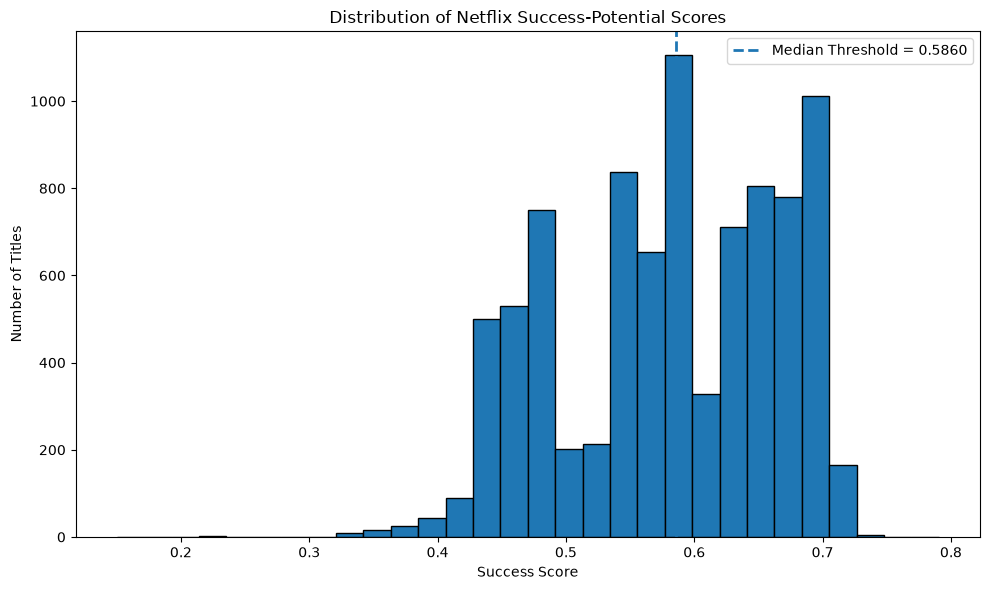


Success Score Summary:
Minimum Score : 0.1500
Mean Score    : 0.5814
Median Score  : 0.5860
Maximum Score : 0.7906
Threshold     : 0.5860


In [16]:
print("=" * 70)
print("VISUAL REPORT 4: SUCCESS SCORE DISTRIBUTION")
print("=" * 70)

plt.figure(figsize=(10, 6))

plt.hist(
    success_df["success_score"],
    bins=30,
    edgecolor="black"
)

plt.axvline(
    success_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Median Threshold = {success_threshold:.4f}"
)

plt.xlabel("Success Score")
plt.ylabel("Number of Titles")
plt.title("Distribution of Netflix Success-Potential Scores")

plt.legend()
plt.tight_layout()
plt.show()

print("\nSuccess Score Summary:")
print(f"Minimum Score : {success_df['success_score'].min():.4f}")
print(f"Mean Score    : {success_df['success_score'].mean():.4f}")
print(f"Median Score  : {success_df['success_score'].median():.4f}")
print(f"Maximum Score : {success_df['success_score'].max():.4f}")
print(f"Threshold     : {success_threshold:.4f}")

## Visual Report 5: Netflix Content Trend by Release Year

This visualization shows the number of Netflix titles released in each year.

Analyzing release-year trends helps identify periods of higher content production and provides context for the project's recency-based success-potential analysis.

VISUAL REPORT 5: CONTENT TREND BY RELEASE YEAR


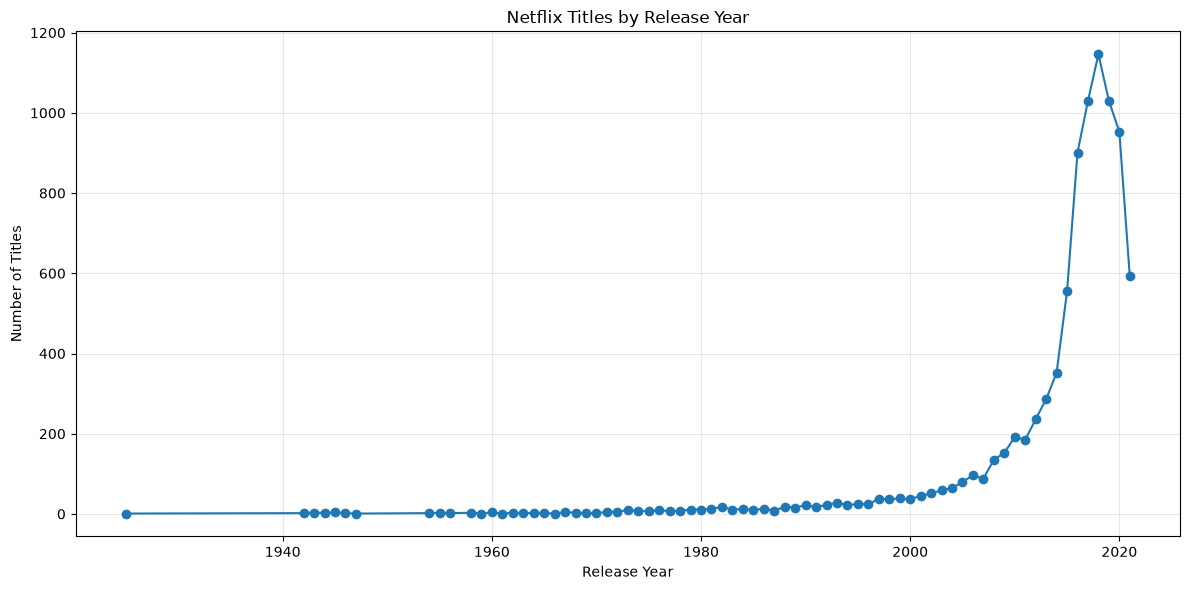


Release-Year Trend Summary:
Peak Release Year: 2018
Titles Released in Peak Year: 1,146
Oldest Release Year: 1925
Latest Release Year: 2021


In [17]:
print("=" * 70)
print("VISUAL REPORT 5: CONTENT TREND BY RELEASE YEAR")
print("=" * 70)

yearly_content = (
    success_df.groupby("release_year")
    .size()
    .reset_index(name="title_count")
    .sort_values("release_year")
)

plt.figure(figsize=(12, 6))

plt.plot(
    yearly_content["release_year"],
    yearly_content["title_count"],
    marker="o"
)

plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.title("Netflix Titles by Release Year")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

peak_year = yearly_content.loc[
    yearly_content["title_count"].idxmax()
]

print("\nRelease-Year Trend Summary:")
print(
    f"Peak Release Year: {int(peak_year['release_year'])}"
)
print(
    f"Titles Released in Peak Year: {int(peak_year['title_count']):,}"
)

print(
    f"Oldest Release Year: "
    f"{int(yearly_content['release_year'].min())}"
)

print(
    f"Latest Release Year: "
    f"{int(yearly_content['release_year'].max())}"
)

## Visual Report 6: Genre Diversity and Success Potential

This visualization compares the average number of genres associated with higher-potential and lower-potential titles.

Genre diversity is one of the components used in the project's success-potential proxy, so this analysis helps explain how genre count contributes to the resulting classification.

VISUAL REPORT 6: GENRE DIVERSITY AND SUCCESS POTENTIAL


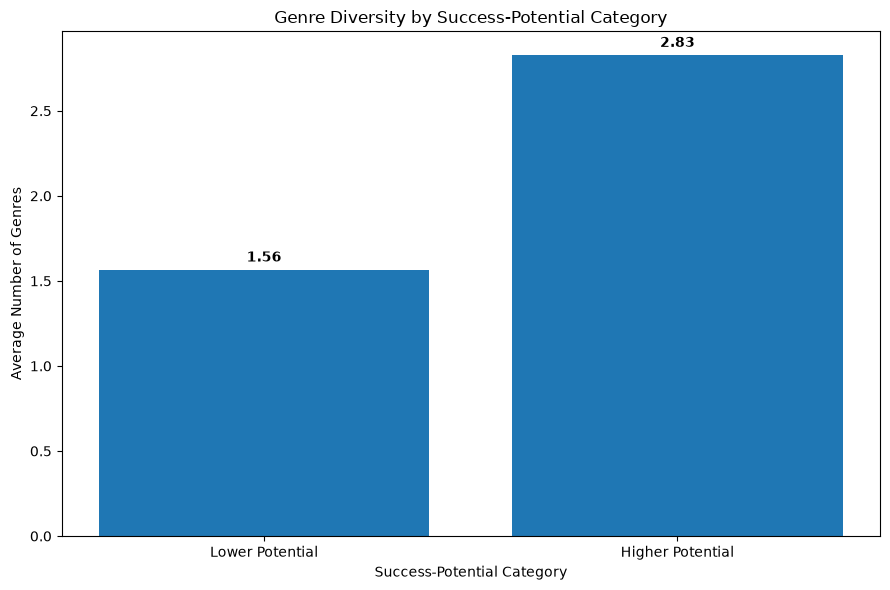


Genre Diversity Summary:
Lower Potential: 1.56 average genres
Higher Potential: 2.83 average genres

Average Genre Difference: 1.26 genres


In [18]:
print("=" * 70)
print("VISUAL REPORT 6: GENRE DIVERSITY AND SUCCESS POTENTIAL")
print("=" * 70)

genre_diversity = (
    success_df.groupby("success_target")["genre_count"]
    .mean()
    .reset_index()
)

genre_diversity["success_category"] = genre_diversity[
    "success_target"
].map({
    0: "Lower Potential",
    1: "Higher Potential"
})

plt.figure(figsize=(9, 6))

bars = plt.bar(
    genre_diversity["success_category"],
    genre_diversity["genre_count"]
)

plt.xlabel("Success-Potential Category")
plt.ylabel("Average Number of Genres")
plt.title("Genre Diversity by Success-Potential Category")

for bar, value in zip(
    bars,
    genre_diversity["genre_count"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.05,
        f"{value:.2f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

print("\nGenre Diversity Summary:")

for _, row in genre_diversity.iterrows():
    print(
        f"{row['success_category']}: "
        f"{row['genre_count']:.2f} average genres"
    )

genre_gap = (
    genre_diversity.loc[
        genre_diversity["success_target"] == 1,
        "genre_count"
    ].iloc[0]
    -
    genre_diversity.loc[
        genre_diversity["success_target"] == 0,
        "genre_count"
    ].iloc[0]
)

print(
    f"\nAverage Genre Difference: {genre_gap:.2f} genres"
)

## Visual Report 7: Recency and Success Potential

This visualization compares the proportion of recent and non-recent titles within the higher-potential and lower-potential categories.

Recency is an important component of the project's success-potential proxy, so this report helps visualize the relationship between content freshness and the constructed target.

VISUAL REPORT 7: RECENCY AND SUCCESS POTENTIAL


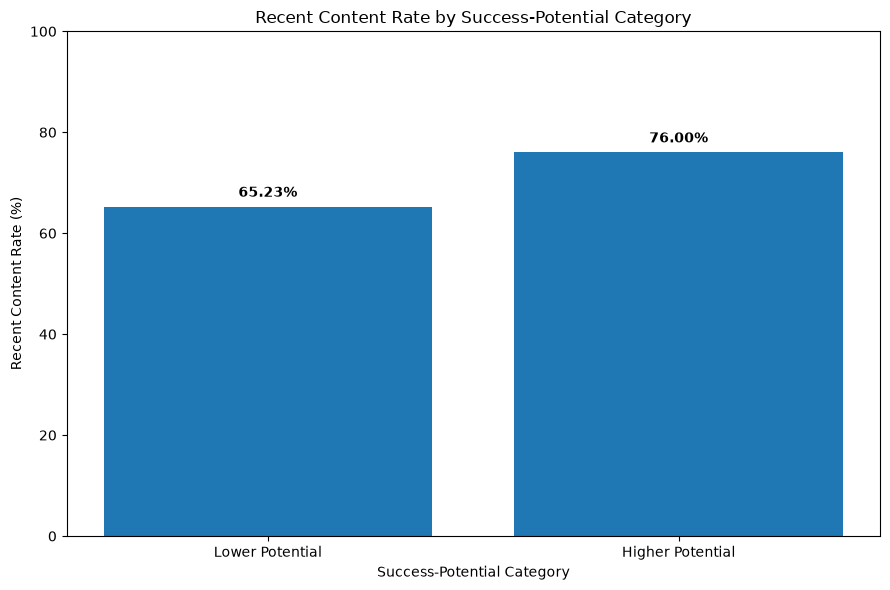


Recency Analysis Summary:
Lower Potential: 65.23% recent content
Higher Potential: 76.00% recent content

Recent Content Rate Difference: 10.76 percentage points


In [19]:
print("=" * 70)
print("VISUAL REPORT 7: RECENCY AND SUCCESS POTENTIAL")
print("=" * 70)

recency_analysis = (
    success_df.groupby("success_target")["is_recent_content"]
    .mean()
    .mul(100)
    .reset_index(name="Recent_Content_Rate")
)

recency_analysis["success_category"] = recency_analysis[
    "success_target"
].map({
    0: "Lower Potential",
    1: "Higher Potential"
})

plt.figure(figsize=(9, 6))

bars = plt.bar(
    recency_analysis["success_category"],
    recency_analysis["Recent_Content_Rate"]
)

plt.xlabel("Success-Potential Category")
plt.ylabel("Recent Content Rate (%)")
plt.title("Recent Content Rate by Success-Potential Category")

plt.ylim(0, 100)

for bar, value in zip(
    bars,
    recency_analysis["Recent_Content_Rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

print("\nRecency Analysis Summary:")

for _, row in recency_analysis.iterrows():
    print(
        f"{row['success_category']}: "
        f"{row['Recent_Content_Rate']:.2f}% recent content"
    )

recent_gap = (
    recency_analysis.loc[
        recency_analysis["success_target"] == 1,
        "Recent_Content_Rate"
    ].iloc[0]
    -
    recency_analysis.loc[
        recency_analysis["success_target"] == 0,
        "Recent_Content_Rate"
    ].iloc[0]
)

print(
    f"\nRecent Content Rate Difference: {recent_gap:.2f} percentage points"
)

## Visual Report 8: Machine Learning Model Performance

This visualization compares the performance of the three machine learning models using Accuracy, Precision, Recall, and F1 Score.

The comparison provides a consolidated view of predictive performance across the evaluated models.

VISUAL REPORT 8: MACHINE LEARNING MODEL PERFORMANCE


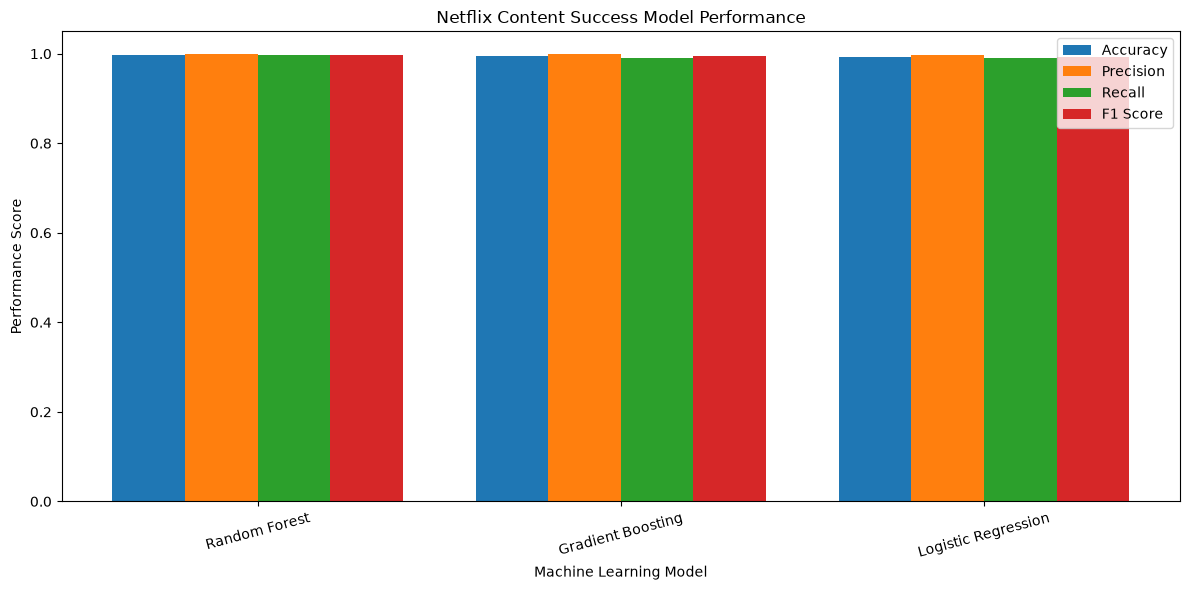


Model Performance Summary:


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.9977,0.9989,0.9966,0.9977
1,Gradient Boosting,0.9943,0.9989,0.9898,0.9943
2,Logistic Regression,0.9937,0.9977,0.9898,0.9937



Highest F1 Score: Random Forest (0.9977)


In [20]:
print("=" * 70)
print("VISUAL REPORT 8: MACHINE LEARNING MODEL PERFORMANCE")
print("=" * 70)

model_metrics = comparison_df.copy()

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

x = np.arange(len(model_metrics))
width = 0.20

plt.figure(figsize=(12, 6))

for i, metric in enumerate(metrics):
    plt.bar(
        x + (i - 1.5) * width,
        model_metrics[metric],
        width,
        label=metric
    )

plt.xlabel("Machine Learning Model")
plt.ylabel("Performance Score")
plt.title("Netflix Content Success Model Performance")

plt.xticks(
    x,
    model_metrics["Model"],
    rotation=15
)

plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

print("\nModel Performance Summary:")

display(
    model_metrics[
        ["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
    ].round(4)
)

print(
    f"\nHighest F1 Score: "
    f"{model_metrics.iloc[0]['Model']} "
    f"({model_metrics.iloc[0]['F1 Score']:.4f})"
)

## Final Automated Business Summary

This section consolidates the major findings from the complete Netflix Content Success Analytics Engine.

The summary combines dataset characteristics, engineered content patterns, success-potential analysis, and machine learning performance into a concise business-oriented report.

The findings represent patterns in the constructed success-potential proxy and should not be interpreted as measured Netflix audience engagement, revenue, or watch-time performance.

In [21]:
print("=" * 70)
print("FINAL AUTOMATED BUSINESS SUMMARY")
print("=" * 70)

# ---------------------------------------------------------
# Core Dataset Metrics
# ---------------------------------------------------------

total_titles = len(success_df)

movie_count = (success_df["type"] == "Movie").sum()
tv_count = (success_df["type"] == "TV Show").sum()

movie_percentage = movie_count / total_titles * 100
tv_percentage = tv_count / total_titles * 100

# ---------------------------------------------------------
# Success-Potential Metrics
# ---------------------------------------------------------

high_count = (success_df["success_target"] == 1).sum()
low_count = (success_df["success_target"] == 0).sum()

high_percentage = high_count / total_titles * 100
low_percentage = low_count / total_titles * 100

high_avg_genres = high_potential["genre_count"].mean()
low_avg_genres = low_potential["genre_count"].mean()

high_recent_rate = high_potential["is_recent_content"].mean() * 100
low_recent_rate = low_potential["is_recent_content"].mean() * 100

# ---------------------------------------------------------
# Release-Year Metrics
# ---------------------------------------------------------

peak_year = int(
    yearly_content.loc[
        yearly_content["title_count"].idxmax(),
        "release_year"
    ]
)

peak_year_count = int(
    yearly_content.loc[
        yearly_content["title_count"].idxmax(),
        "title_count"
    ]
)

# ---------------------------------------------------------
# Model Metrics
# ---------------------------------------------------------

top_model = comparison_df.iloc[0]

# ---------------------------------------------------------
# Final Report
# ---------------------------------------------------------

print("\nDATASET OVERVIEW")
print("-" * 50)

print(f"Total Titles Analyzed : {total_titles:,}")
print(f"Movies                : {movie_count:,} ({movie_percentage:.2f}%)")
print(f"TV Shows              : {tv_count:,} ({tv_percentage:.2f}%)")

print("\nSUCCESS-POTENTIAL ANALYSIS")
print("-" * 50)

print(
    f"Higher-Potential Titles : "
    f"{high_count:,} ({high_percentage:.2f}%)"
)

print(
    f"Lower-Potential Titles  : "
    f"{low_count:,} ({low_percentage:.2f}%)"
)

print(
    f"Success Threshold       : "
    f"{success_threshold:.4f}"
)

print(
    f"Higher-Potential Average Genres : "
    f"{high_avg_genres:.2f}"
)

print(
    f"Lower-Potential Average Genres  : "
    f"{low_avg_genres:.2f}"
)

print(
    f"Higher-Potential Recent Rate : "
    f"{high_recent_rate:.2f}%"
)

print(
    f"Lower-Potential Recent Rate  : "
    f"{low_recent_rate:.2f}%"
)

print("\nCONTENT TREND")
print("-" * 50)

print(
    f"Peak Release Year : "
    f"{peak_year}"
)

print(
    f"Titles in Peak Year : "
    f"{peak_year_count:,}"
)

print(
    f"Release Year Range : "
    f"{success_df['release_year'].min()} - "
    f"{success_df['release_year'].max()}"
)

print("\nMACHINE LEARNING PERFORMANCE")
print("-" * 50)

print(
    f"Top Model by F1 Score : "
    f"{top_model['Model']}"
)

print(
    f"Accuracy              : "
    f"{top_model['Accuracy']:.4f}"
)

print(
    f"Precision             : "
    f"{top_model['Precision']:.4f}"
)

print(
    f"Recall                : "
    f"{top_model['Recall']:.4f}"
)

print(
    f"F1 Score              : "
    f"{top_model['F1 Score']:.4f}"
)

print("\nKEY BUSINESS INSIGHTS")
print("-" * 50)

print(
    f"1. Movies account for {movie_percentage:.2f}% "
    f"of the analyzed Netflix titles."
)

print(
    f"2. The dataset contains {high_percentage:.2f}% "
    f"higher-potential and {low_percentage:.2f}% lower-potential titles "
    f"because the median success score was used as the classification threshold."
)

print(
    f"3. Higher-potential titles contain an average of "
    f"{high_avg_genres:.2f} genres, compared with "
    f"{low_avg_genres:.2f} genres for lower-potential titles."
)

print(
    f"4. Recent content represents {high_recent_rate:.2f}% "
    f"of higher-potential titles compared with "
    f"{low_recent_rate:.2f}% of lower-potential titles."
)

print(
    f"5. The highest number of titles in a single release year "
    f"occurred in {peak_year}, with {peak_year_count:,} titles."
)

print(
    f"6. {top_model['Model']} achieved the highest F1 Score "
    f"among the evaluated models ({top_model['F1 Score']:.4f})."
)

print(
    "\nIMPORTANT LIMITATION:"
)

print(
    "The success target is a constructed proxy based on content "
    "characteristics. The dataset does not contain actual views, "
    "watch time, revenue, or audience engagement. Therefore, the "
    "model performance should not be interpreted as real-world "
    "Netflix success prediction accuracy."
)

print("\n" + "=" * 70)
print("FINAL BUSINESS SUMMARY COMPLETED")
print("=" * 70)

FINAL AUTOMATED BUSINESS SUMMARY

DATASET OVERVIEW
--------------------------------------------------
Total Titles Analyzed : 8,790
Movies                : 6,126 (69.69%)
TV Shows              : 2,664 (30.31%)

SUCCESS-POTENTIAL ANALYSIS
--------------------------------------------------
Higher-Potential Titles : 4,395 (50.00%)
Lower-Potential Titles  : 4,395 (50.00%)
Success Threshold       : 0.5860
Higher-Potential Average Genres : 2.83
Lower-Potential Average Genres  : 1.56
Higher-Potential Recent Rate : 76.00%
Lower-Potential Recent Rate  : 65.23%

CONTENT TREND
--------------------------------------------------
Peak Release Year : 2018
Titles in Peak Year : 1,146
Release Year Range : 1925 - 2021

MACHINE LEARNING PERFORMANCE
--------------------------------------------------
Top Model by F1 Score : Random Forest
Accuracy              : 0.9977
Precision             : 0.9989
Recall                : 0.9966
F1 Score              : 0.9977

KEY BUSINESS INSIGHTS
------------------------

## Final Project Conclusion

The Netflix Content Success Analytics Engine successfully analyzed 8,790 Netflix titles using advanced feature engineering, success-potential classification, multiple machine learning models, automated business insights, and visual reports.

The analysis identified differences in content type, genre diversity, content recency, release-year patterns, and the constructed success-potential categories. Movies represented 69.69% of the dataset, while TV Shows represented 30.31%.

Higher-potential titles had an average of 2.83 genres compared with 1.56 genres for lower-potential titles. Recent content also appeared more frequently among higher-potential titles (76.00%) than lower-potential titles (65.23%).

Three machine learning models were evaluated: Logistic Regression, Random Forest, and Gradient Boosting. Random Forest achieved the highest F1 Score among the evaluated models at 0.9977.

However, the success target used in this project is a constructed proxy derived from content characteristics such as recency, genre count, country count, director availability, and duration. The dataset does not contain actual Netflix performance indicators such as views, watch time, revenue, ratings from users, or audience engagement.

Therefore, the very high model scores should not be interpreted as evidence that the system can accurately predict real-world Netflix content success. Because the target is derived from features related to the model inputs, the evaluation contains target leakage/circularity. A future version should use independent outcome data, such as views, watch hours, revenue, or audience engagement, to build and evaluate a genuine content-success prediction model.

Overall, the project demonstrates an end-to-end machine learning workflow covering feature engineering, target construction, preprocessing, model training, evaluation, business insight generation, and visual reporting.

In [22]:
print("=" * 70)
print("NETFLIX CONTENT SUCCESS ANALYTICS ENGINE")
print("FINAL PROJECT CONCLUSION")
print("=" * 70)

print("\nPROJECT STATUS")
print("-" * 50)

print("✓ Dataset loaded and inspected")
print("✓ Advanced feature engineering completed")
print("✓ Success-potential target constructed")
print("✓ Train/test split completed")
print("✓ ML preprocessing pipeline completed")
print("✓ Multiple machine learning models trained")
print("✓ Model performance compared")
print("✓ Automated business insights generated")
print("✓ Visual business reports generated")
print("✓ Final business summary generated")

print("\nFINAL PROJECT STATISTICS")
print("-" * 50)

print(f"Total Netflix Titles Analyzed : {total_titles:,}")
print(f"Movies                        : {movie_percentage:.2f}%")
print(f"TV Shows                      : {tv_percentage:.2f}%")
print(f"Higher-Potential Titles       : {high_percentage:.2f}%")
print(f"Lower-Potential Titles        : {low_percentage:.2f}%")
print(f"Peak Release Year             : {peak_year}")
print(f"Peak Year Title Count         : {peak_year_count:,}")

print("\nMODEL EVALUATION")
print("-" * 50)

print(f"Evaluated Models              : {len(comparison_df)}")
print(f"Highest F1 Score Model        : {top_model['Model']}")
print(f"Highest F1 Score              : {top_model['F1 Score']:.4f}")

print("\nIMPORTANT PROJECT LIMITATION")
print("-" * 50)

print(
    "The success target is a constructed proxy based on content "
    "features rather than actual audience or financial outcomes."
)

print(
    "Therefore, the high model scores should not be interpreted "
    "as real-world Netflix success prediction accuracy."
)

print(
    "Future improvement: use independent outcome variables such "
    "as views, watch time, revenue, or audience engagement."
)

print("\n" + "=" * 70)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 70)

NETFLIX CONTENT SUCCESS ANALYTICS ENGINE
FINAL PROJECT CONCLUSION

PROJECT STATUS
--------------------------------------------------
✓ Dataset loaded and inspected
✓ Advanced feature engineering completed
✓ Success-potential target constructed
✓ Train/test split completed
✓ ML preprocessing pipeline completed
✓ Multiple machine learning models trained
✓ Model performance compared
✓ Automated business insights generated
✓ Visual business reports generated
✓ Final business summary generated

FINAL PROJECT STATISTICS
--------------------------------------------------
Total Netflix Titles Analyzed : 8,790
Movies                        : 69.69%
TV Shows                      : 30.31%
Higher-Potential Titles       : 50.00%
Lower-Potential Titles        : 50.00%
Peak Release Year             : 2018
Peak Year Title Count         : 1,146

MODEL EVALUATION
--------------------------------------------------
Evaluated Models              : 3
Highest F1 Score Model        : Random Forest
Highest F1 